In [1]:
import torch
import lightning
import copy
from mlcolvar.cvs import BaseCV
from mlcolvar.core import FeedForward
import numpy as np
from mlcolvar.data import DictDataset
from mlcolvar.cvs.committor.utils import compute_committor_weights
from mlcolvar.cvs.generator import Generator
import MDAnalysis as mda
from mlcolvar.cvs.committor.utils import compute_committor_weights
from mlcolvar.core.transform.descriptors import ReducedFFEnergy
from mlcolvar.core.transform.tools import LogHistogram
from mlcolvar.core.loss.utils.smart_derivatives import compute_descriptors_derivatives
from mlcolvar.cvs.indicator import IndicatorTraining, IndicatorProduction, IndicatorBiasModel
from mlcolvar.data import DictModule
from mlcolvar.utils.trainer import MetricsCallback
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
import matplotlib.pyplot as plt
from mlcolvar.utils.plot import plot_metrics

torch.set_default_dtype(torch.float64)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/home/fdietrich@iit.local/miniconda3/envs/ensemblecolvar/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/fdietrich@iit.local/programmes/mlcolvar-dev/EnsembleDynamicsColvar/mlcolvar/cvs/generator/utils.py:35: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  Hyperparameter for the shift to define the resolvent, i.e., $(\eta I-_mathcal{L})^{-1}$
/home/fdietrich@iit.local/programmes/mlcolvar-dev/EnsembleDynamicsColvar/mlcolvar/cvs/indicator/indicator.py:25: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  Hyperparameter for the shift to define the resolvent, i.e., $(\eta I-_mathcal{L})^{-1}$


# Step 1: Prepare Settings and Load Data

In [2]:
cell = torch.Tensor([3.0233, 3.0233, 3.0233]).to(device)
print('Cell: ', cell)
# temperature in Kelvin
T = 300 
# Boltzmann factor in the RIGHT ENRGY UNITS!
kb = 0.0083144621
beta = 1/(kb*T)
kT = 1/beta
print(f'Beta: {beta} \n1/beta: {1/beta}')

Cell:  tensor([3.0233, 3.0233, 3.0233], device='cuda:0')
Beta: 0.4009078751268027 
1/beta: 2.4943386299999997


In [3]:
# Load unbiased trajectory data
# Here from as many bursts as there are walkers
# Alternatively draw n_rep random samples from the unbiased trajectory and use them as separate replicas
n_rep = 20
pos_A = np.zeros((1001, n_rep,22*3))

for i in range(n_rep):
    u_A = mda.Universe("../../../../Paper/Ala2/unbiased/A/%d/%d.gro" % (i, i), "../../../../Paper/Ala2/unbiased/A/%d/traj_comp.xtc" % i)
    pos_folded = []
    for t in u_A.trajectory:
        ats = u_A.atoms.select_atoms("all")
        pos = ats.atoms.positions / 10.0
        pos_tensor = torch.tensor(pos.flatten(), dtype=torch.get_default_dtype()).view(1, -1)
        pos_folded.append(pos_tensor)

    pos_A[:,i,:] = torch.cat(pos_folded[::10], dim=0).numpy()

In [4]:
# Concatenate all data sources (here only one) and create a dataset
labels_folded = torch.zeros(pos_A.shape[0])
pos_all = torch.cat([torch.tensor(pos_A).reshape(1001, n_rep*22*3)])
labels_all = torch.cat([labels_folded])

ds_unbiased = DictDataset({"data": pos_all, "labels": labels_all})

In [5]:
T = 300
kb = 0.0083144621 # kJ/mol
beta = 1/(kb*T)
# zeroth iteration should be unbiased, we thus initialise the bias as zero

# compute weights
ds = compute_committor_weights(dataset=ds_unbiased,
                                    bias=torch.zeros(len(pos_all)),
                                    data_groups=[0],
                                    beta=beta)


# Identify indices of heavy atoms for biasing
ats = u_A.atoms.select_atoms("protein")
heavy = ats.select_atoms("protein and not name H*")
heavy_indices = heavy.indices

# Step 2: Define the Descriptor and Preprocessing Layer
- Plot average energy distributions for your known state
- Define a reasonable range for the histogram leaving room for lower and/or higher energy states
- This choice is not critical and can be modified in following iterations in case states are encountered that fall outside of the range

In [6]:
# Descriptors

n_at = 22
mm_energy = ReducedFFEnergy.from_files(
    n_atoms=n_at,
    bonds_file="../sim_template/bonds_mm.dat",
    angles_file="../sim_template/angles_mm.dat",
    dihedrals_file="../sim_template/dihedrals_mm.dat",
    lj_peratom_file="../sim_template/lj_peratom_mm.dat",
    use_lj=True,
    lj_cutoff=1.2,
    lj_comb="LB",
    use_coulomb=True,
    charges_file="../sim_template/charges_mm.dat",
    epsilon_r=1,
    exclude12=True,
    exclude13=True,
    scale14=0,
    box = [3.024, 3.024, 3.024],
    #force_atoms = heavy_indices,
    n_replicas=n_rep
)

hist_ene = LogHistogram(in_features=20, min=-380, max=-300, bins=20)
preprocessing_ene = torch.nn.Sequential(mm_energy, hist_ene)

# 

In [7]:
pos, desc, d_desc_d_pos = compute_descriptors_derivatives(ds, preprocessing_ene, n_rep*22, separate_boundary_dataset = False, batch_size=512)
dataset = DictDataset({"data":desc.clone().detach().to(device), "weights":ds["weights"].to(device),"derivatives":d_desc_d_pos.clone().detach().to(device)})#30 2500 epochs

Processed all data in 2 batches!


In [8]:
ats = u_A.atoms.select_atoms("protein")
atomic_masses = torch.repeat_interleave(torch.tensor(ats.masses),n_rep)

n_atoms = n_rep*22
gamma = 1/0.05
friction = np.zeros(n_atoms*3)
print(friction.shape)
for i_atom in range(n_atoms):
    friction[3*i_atom:3*i_atom+3] = np.array([kT / (gamma*atomic_masses[i_atom])]*3) 
cell = torch.Tensor([3.0233, 3.0233, 3.0233]).to(device)
#cell = torch.ones(91*3).to(device)*3.961
friction = torch.tensor(friction, device=device,dtype=torch.float32)

(1320,)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type          | Params | Mode  | FLOPs | In sizes | Out sizes
---------------------------------------------------------------------------------
0 | loss_fn | GeneratorLoss | 1      | train | 0     | ?        | ?        
1 | nn      | FeedForward   | 1.8 K  | train | 3.4 K | [1, 20]  | [1, 1]   
---------------------------------------------------------------------------------
1.8 K     Trainable params
0         Non-trainable params
1.8 K     Total params
0.007     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode
3.4 K     Total Flops


Epoch 0:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 999: 100%|██████████| 1/1 [00:00<00:00, 27.04it/s]

`Trainer.fit` stopped: `max_epochs=1000` reached.


Epoch 999: 100%|██████████| 1/1 [00:00<00:00, 23.04it/s]
lambda_value tensor(10.2937, dtype=torch.float32)


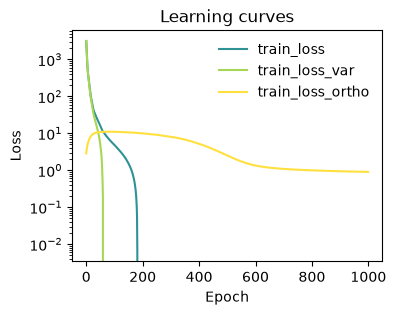

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
options = {
    "nn": {"activation": "tanh"},
    "optimizer": {"lr": 5e-4, "weight_decay": 1e-5},
}

# Keep model hyperparameters explicit so they can be reused consistently later.
layers = [20, 32, 32, 1]
eta = 0.05
alpha = 20

# Detach dataset tensors to ensure they are leaf variables for each new model (relevant for training multiple models in a loop)
# and keep them on the active device used for training.
dataset_iter = DictDataset(
    {
        "data": dataset["data"].detach().clone().to(device),
        "weights": dataset["weights"].detach().clone().to(device),
        "derivatives": dataset["derivatives"].detach().clone().to(device),
    }
)

model = IndicatorTraining(
    layers=layers,
    eta=eta,
    alpha=alpha,
    friction=friction.to(device),
    options=options,
).to(device)

datamodule = DictModule(dataset_iter, lengths=[0.8, 0.2])
metrics = MetricsCallback()
trainer = lightning.Trainer(
    callbacks=[metrics],
    max_epochs=1000,
    enable_checkpointing=False,
    logger=False,
    limit_val_batches=0,
    num_sanity_val_steps=0,
)

# fit model
trainer.fit(model, datamodule)

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax = plot_metrics(
    metrics.metrics,
    keys=["train_loss", "train_loss_var", "train_loss_ortho"],
    colors=["fessa1", "fessa3", "fessa4", "fessa5"],
    ax=ax,
    yscale="log",
)

# Ensure model and evaluation tensors are on the same device before post-training inference.
model_device = next(model.parameters()).device
dataset_eval = DictDataset(
    {
        "data": dataset_iter["data"].to(model_device),
        "weights": dataset_iter["weights"].to(model_device),
        "derivatives": dataset_iter["derivatives"].to(model_device),
    }
)

g, evals, evecs = model.compute_eigenfunctions(dataset_eval)
coeffs = evecs.cpu().detach().real

# Set up the production model with the trained weights and computed coefficients
trivial = IndicatorProduction(
    layers=layers,
    eta=eta,
    alpha=alpha,
    friction=friction.cpu(),
    coeffs=coeffs[:, 0],
).to("cpu").to(torch.float32)

# Copy NN weights from trained model
trivial.nn = copy.deepcopy(model.nn).to("cpu").to(torch.float32)

# Estimate the lambda parameter for biasing
bias = IndicatorBiasModel(model.to("cpu"), l=1, e=1e-7).to(torch.float32)
bias_values = bias(dataset_eval["data"].cpu().detach())
lambda_value = 40 / (bias_values.max() - bias_values.min())
print("lambda_value", lambda_value)

In [ ]:
def convert_model(model_name, n_input):
    loaded_model = torch.jit.load(model_name).to(torch.device('cpu')).to(torch.float32)
    fake_input = torch.rand(1,n_input,dtype=torch.float32).to(torch.device('cpu')).to(torch.float32)
    loaded_model(fake_input)
    frozen_model = torch.jit.trace(loaded_model, fake_input)
    torch.jit.save(frozen_model, model_name)

In [ ]:
trivial.preprocessing = LogHistogram32(in_features=20, min=-380, max=-300, bins=20)
traced_model = trivial.to("cpu").to_torchscript(file_path=f'model_trivial.pt', method='trace')
convert_model(f'model_trivial.pt',20)